# 05 — Tumor and Epithelial Cell Heterogeneity

## Objective

This notebook investigates transcriptional heterogeneity within the
epithelial/tumor cell compartment of the CID4465 triple-negative breast
cancer (TNBC) single-cell dataset.

The analysis will:

1. Identify and isolate epithelial/tumor cells.
2. Re-cluster the tumor compartment.
3. Identify transcriptionally distinct tumor cell states.
4. Characterize cluster-specific marker genes.
5. Visualize intratumoral heterogeneity within the TNBC sample.

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sc.settings.verbosity = 2
sc.set_figure_params(figsize=(6, 5), dpi=100)

print("Scanpy version:", sc.__version__)

Scanpy version: 1.12.4


/var/folders/gr/dczgzvyn4w1c3nb_7lb1vr7m0000gn/T/ipykernel_3427/1794720870.py:10: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy version:", sc.__version__)


In [2]:
# Project paths
project_dir = Path("..")
data_dir = project_dir / "data" / "processed"
results_dir = project_dir / "results"
figures_dir = project_dir / "figures"

results_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

adata_path = data_dir / "CID4465_processed.h5ad"

print("AnnData path:", adata_path)
print("File exists:", adata_path.exists())

AnnData path: ../data/processed/CID4465_processed.h5ad
File exists: True


In [4]:
# Load processed single-cell dataset
adata = sc.read_h5ad(adata_path)

print(adata)
print("\nShape:", adata.shape)
print("\nAvailable metadata columns:")
print(adata.obs.columns.tolist())

AnnData object with n_obs × n_vars = 1534 × 13514
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', None (.X)

Shape: (1534, 13514)

Available metadata columns:
['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype']


In [5]:
# Inspect available cell-type annotations

for col in ["celltype_major", "celltype_minor", "celltype_subset"]:
    if col in adata.obs.columns:
        print(f"\n=== {col} ===")
        print(adata.obs[col].value_counts(dropna=False))


=== celltype_major ===
celltype_major
CAFs                 376
PVL                  314
Endothelial          285
Myeloid              178
T-cells              116
Cancer Epithelial    113
Plasmablasts         110
B-cells               33
Normal Epithelial      9
Name: count, dtype: int64

=== celltype_minor ===
celltype_minor
CAFs myCAF-like                246
Endothelial ACKR1              188
PVL Differentiated             185
CAFs MSC iCAF-like             130
PVL Immature                   122
Plasmablasts                   110
Macrophage                     109
Cancer Cycling                  89
T cells CD4+                    64
Endothelial CXCL12              50
Monocyte                        36
T cells CD8+                    35
Endothelial RGS5                34
B cells Memory                  33
Cycling_Myeloid                 21
Cancer Basal SC                 19
Endothelial Lymphatic LYVE1     13
DCs                             12
Cycling T-cells                 10
Cyclin

In [6]:
# Subset cancer epithelial cells

tumor = adata[adata.obs["celltype_major"] == "Cancer Epithelial"].copy()

print(tumor)
print("\nTumor cell shape:", tumor.shape)

print("\nTumor cell-type composition:")
print(tumor.obs["celltype_minor"].value_counts())

print("\nDetailed tumor subsets:")
print(tumor.obs["celltype_subset"].value_counts())

AnnData object with n_obs × n_vars = 113 × 13514
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', None (.X)

Tumor cell shape: (113, 13514)

Tumor cell-type composition:
celltype_minor
Cancer Cycling     89
Cancer Basal SC    19
Cancer LumB SC      5
Name: count, dtype: int64

Detailed tumor subsets:
celltype_subset
Cancer Cycling     89
Cancer Basal SC    19
Cancer LumB SC      5
Name: count, dtype: int64


In [7]:
# Inspect tumor AnnData structure before re-clustering

print("Tumor AnnData:")
print(tumor)

print("\nNumber of cells:", tumor.n_obs)
print("Number of genes:", tumor.n_vars)

print("\nAvailable layers:")
print(list(tumor.layers.keys()))

print("\nRaw available:")
print(tumor.raw is not None)

if tumor.raw is not None:
    print("Raw shape:", tumor.raw.shape)

print("\nFirst 20 variable names:")
print(tumor.var_names[:20].tolist())

Tumor AnnData:
AnnData object with n_obs × n_vars = 113 × 13514
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', None (.X)

Number of cells: 113
Number of genes: 13514

Available layers:
['counts', None]

Raw available:
False

First 20 variable names:
['FO538757.2', 'AP006222.2', 'RP11-206L10.9', 'LINC00115', 'FAM41C', 'SAMD11', 'NOC2L', 'PLEKHN1', 'RP11-54O7.17', 'HES4', 'ISG15', 'AGRN', 'C1orf159', 'TNFRSF18', 'TNFRSF4', 'SDF4', 'B3GALT6', 'FAM132A', 'UBE2J2', 'ACAP3']


In [8]:
# Reconstruct tumor-only expression matrix from raw counts

tumor.X = tumor.layers["counts"].copy()

print("Tumor matrix reset to raw counts.")
print("Shape:", tumor.shape)

print("\nExpression range:")
print("Min:", tumor.X.min())
print("Max:", tumor.X.max())

Tumor matrix reset to raw counts.
Shape: (113, 13514)

Expression range:
Min: 0
Max: 267


In [9]:
# Normalize tumor-cell expression independently

sc.pp.normalize_total(
    tumor,
    target_sum=1e4
)

sc.pp.log1p(tumor)

print("Tumor-specific normalization and log1p transformation complete.")

normalizing counts per cell
    finished (0:00:01)
Tumor-specific normalization and log1p transformation complete.


In [10]:
# Identify highly variable genes within tumor cells

sc.pp.highly_variable_genes(
    tumor,
    n_top_genes=1500,
    flavor="seurat"
)

n_hvg = tumor.var["highly_variable"].sum()

print("Number of tumor-specific HVGs:", n_hvg)

extracting highly variable genes
    finished (0:00:00)
Number of tumor-specific HVGs: 1500


In [11]:
print(
    tumor.var_names[tumor.var["highly_variable"]][:30].tolist()
)

['HES4', 'ISG15', 'AGRN', 'FAM132A', 'MXRA8', 'ATAD3C', 'RP11-345P4.9', 'MORN1', 'MEGF6', 'RP4-635E18.6', 'MTOR', 'FBXO6', 'MTHFR', 'NBL1', 'KDM1A', 'HNRNPR', 'ID3', 'LDLRAP1', 'CD52', 'FAM46B', 'SYTL1', 'FAM76A', 'SESN2', 'PHACTR4', 'GMEB1', 'SRSF4', 'LAPTM5', 'TXLNA', 'YARS', 'ZMYM4']


In [12]:
# Preserve full normalized expression matrix for marker-gene analysis

tumor.raw = tumor

print("Full normalized tumor expression stored in tumor.raw")
print("Raw shape:", tumor.raw.shape)

Full normalized tumor expression stored in tumor.raw
Raw shape: (113, 13514)


In [13]:
tumor_hvg = tumor[:, tumor.var["highly_variable"]].copy()

print("Tumor HVG matrix:")
print(tumor_hvg)

Tumor HVG matrix:
AnnData object with n_obs × n_vars = 113 × 1500
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', None (.X)


In [14]:
# Scale tumor-specific HVGs

sc.pp.scale(
    tumor_hvg,
    max_value=10
)

# PCA
sc.tl.pca(
    tumor_hvg,
    n_comps=30,
    svd_solver="arpack"
)

print("PCA completed.")
print("PCA coordinates:", tumor_hvg.obsm["X_pca"].shape)

computing PCA
    with n_comps=30
    finished (0:00:00)
PCA completed.
PCA coordinates: (113, 30)


/opt/anaconda3/envs/cancer-informatics/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [15]:
pca_variance = tumor_hvg.uns["pca"]["variance_ratio"]

print("Variance explained by first 10 PCs:")

for i, variance in enumerate(pca_variance[:10], start=1):
    print(f"PC{i}: {variance * 100:.2f}%")

print(
    f"\nCumulative variance PC1-PC10: "
    f"{pca_variance[:10].sum() * 100:.2f}%"
)

Variance explained by first 10 PCs:
PC1: 3.41%
PC2: 3.09%
PC3: 2.88%
PC4: 2.83%
PC5: 2.72%
PC6: 2.68%
PC7: 2.59%
PC8: 2.47%
PC9: 2.40%
PC10: 2.35%

Cumulative variance PC1-PC10: 27.40%


In [16]:
# Construct tumor-cell neighborhood graph

sc.pp.neighbors(
    tumor_hvg,
    n_neighbors=10,
    n_pcs=15
)

# Compute UMAP
sc.tl.umap(
    tumor_hvg,
    random_state=42
)

print("Neighbor graph and UMAP completed.")
print("UMAP coordinates:", tumor_hvg.obsm["X_umap"].shape)

computing neighbors
    using 'X_pca' with n_pcs = 15


/opt/anaconda3/envs/cancer-informatics/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished (0:00:05)
computing UMAP
    finished (0:00:00)
Neighbor graph and UMAP completed.
UMAP coordinates: (113, 2)


In [17]:
# Compare Leiden clustering across conservative resolutions

resolutions = [0.2, 0.3, 0.4, 0.5]

for res in resolutions:
    key = f"leiden_{res}"

    sc.tl.leiden(
        tumor_hvg,
        resolution=res,
        key_added=key,
        flavor="igraph",
        n_iterations=2,
        random_state=42
    )

    print(f"\n=== Resolution {res} ===")
    print(tumor_hvg.obs[key].value_counts().sort_index())

running Leiden clustering
    finished (0:00:00)

=== Resolution 0.2 ===
leiden_0.2
0    113
Name: count, dtype: int64
running Leiden clustering
    finished (0:00:00)

=== Resolution 0.3 ===
leiden_0.3
0    113
Name: count, dtype: int64
running Leiden clustering
    finished (0:00:00)

=== Resolution 0.4 ===
leiden_0.4
0    83
1    30
Name: count, dtype: int64
running Leiden clustering
    finished (0:00:00)

=== Resolution 0.5 ===
leiden_0.5
0    40
1    31
2    42
Name: count, dtype: int64


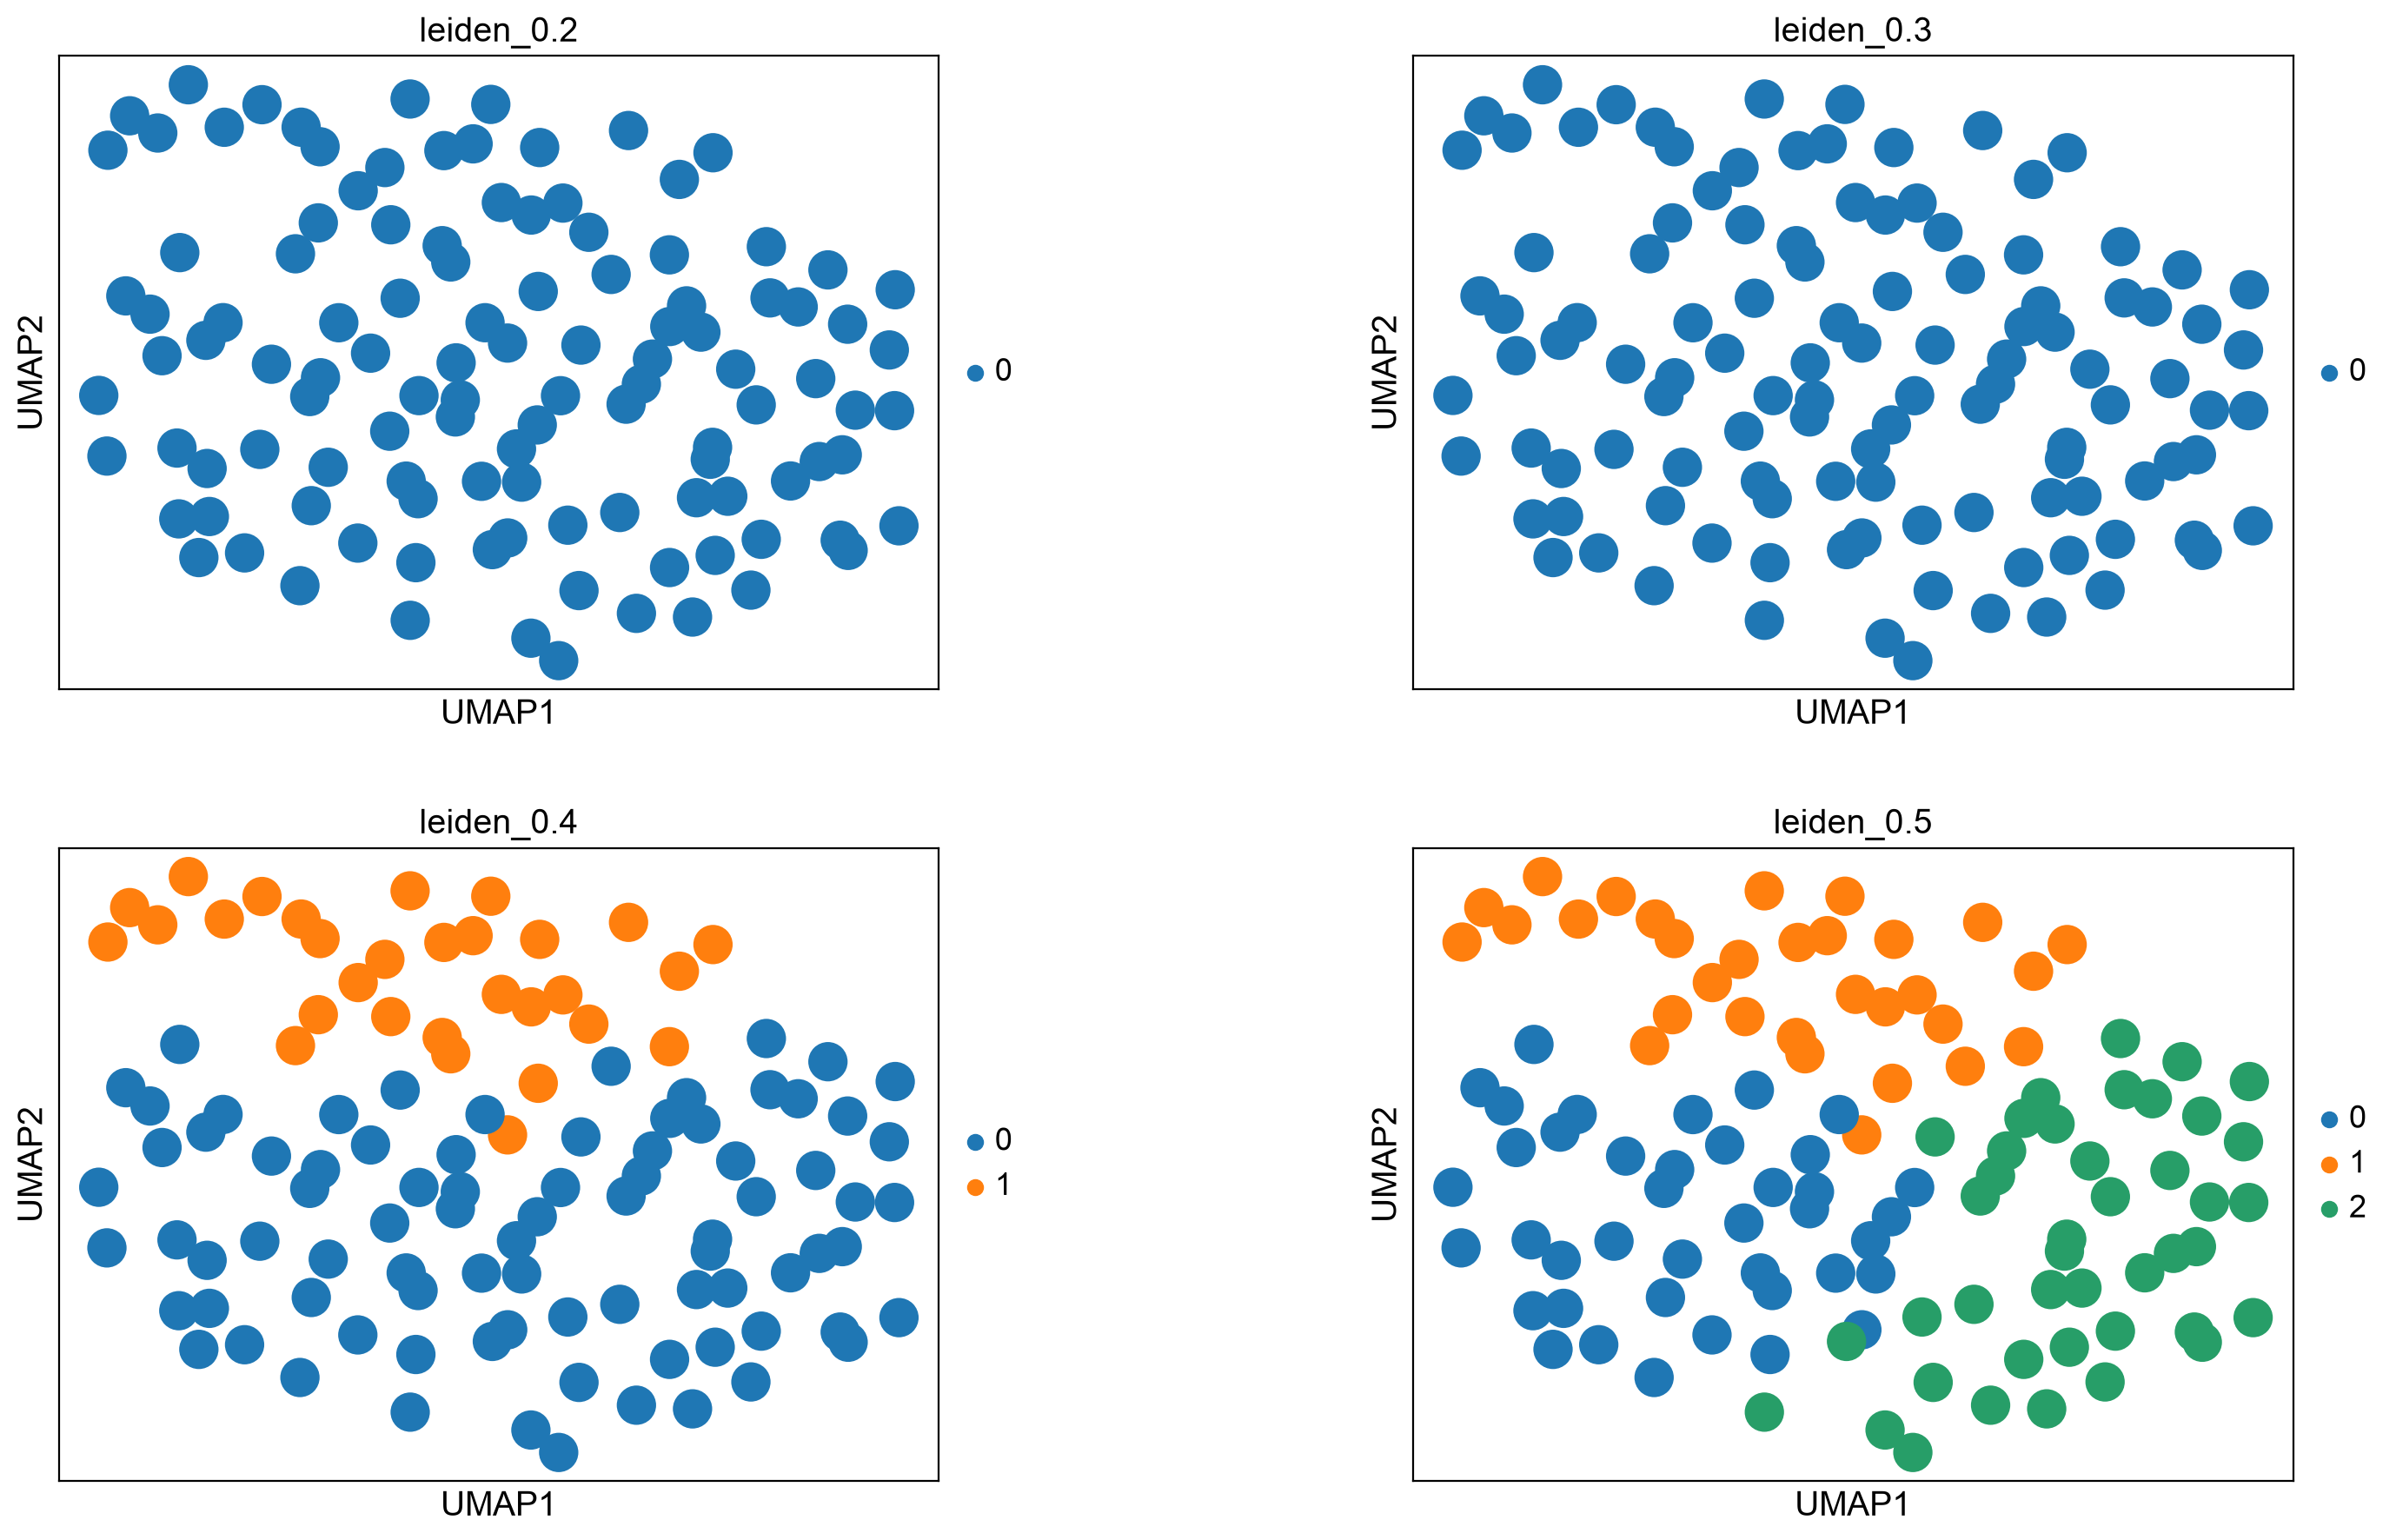

In [18]:
# Visualize clustering across resolutions

sc.pl.umap(
    tumor_hvg,
    color=[
        "leiden_0.2",
        "leiden_0.3",
        "leiden_0.4",
        "leiden_0.5"
    ],
    ncols=2,
    wspace=0.4,
    show=True
)

In [19]:
# Compare unsupervised tumor clustering with original annotations

print(
    tumor_hvg.obs[
        [
            "celltype_major",
            "celltype_minor",
            "celltype_subset"
        ]
    ].head()
)

                             celltype_major  celltype_minor celltype_subset
CID4465_AATCCAGTCGGAATCT  Cancer Epithelial  Cancer LumB SC  Cancer LumB SC
CID4465_AGGCCACTCAATCACG  Cancer Epithelial  Cancer LumB SC  Cancer LumB SC
CID4465_ATCACGACAATCGGTT  Cancer Epithelial  Cancer LumB SC  Cancer LumB SC
CID4465_CTACACCTCGAGCCCA  Cancer Epithelial  Cancer LumB SC  Cancer LumB SC
CID4465_TGGTTAGGTATAAACG  Cancer Epithelial  Cancer LumB SC  Cancer LumB SC


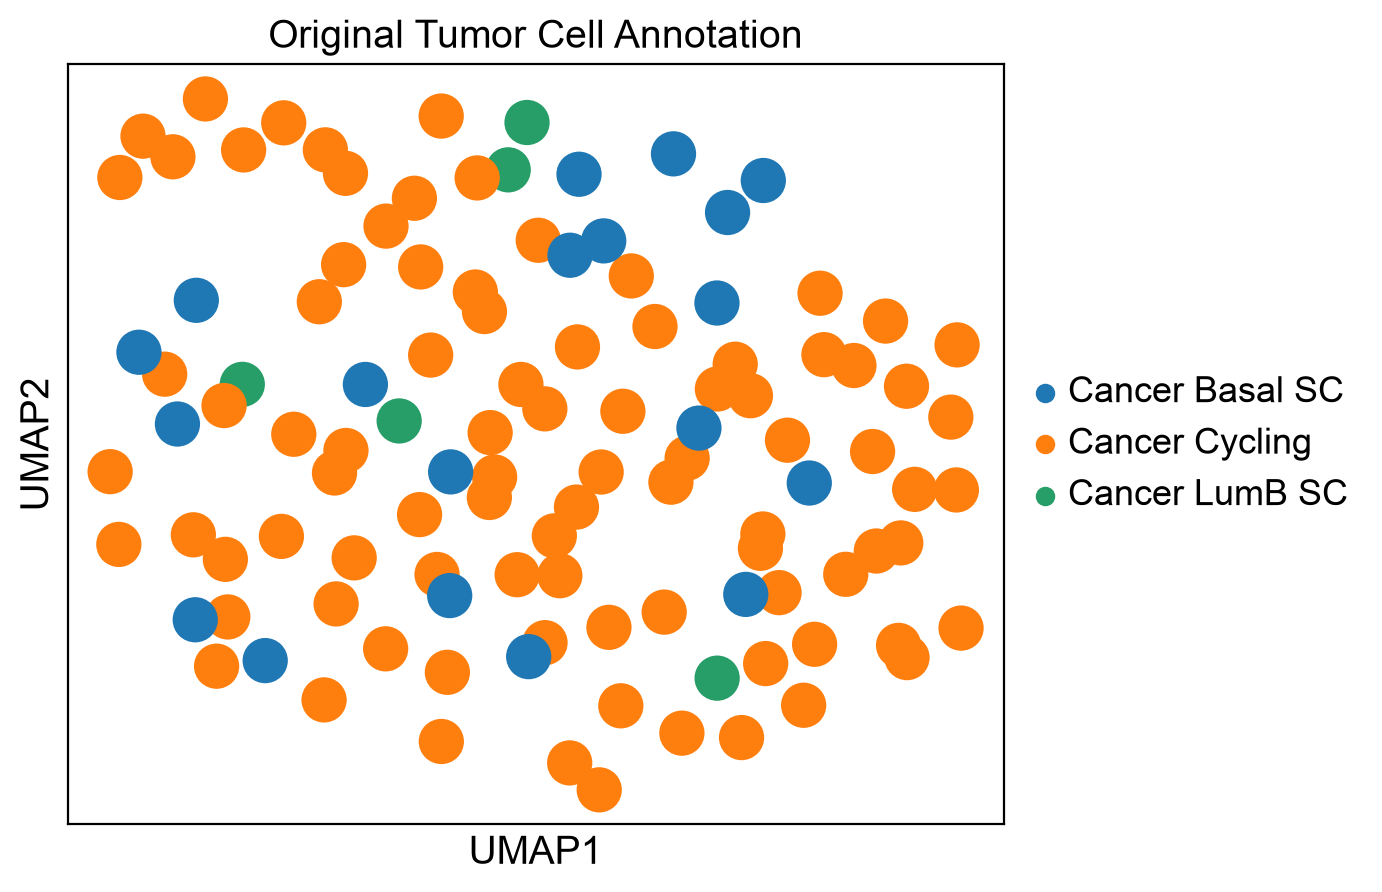

In [20]:
sc.pl.umap(
    tumor_hvg,
    color="celltype_minor",
    title="Original Tumor Cell Annotation",
    legend_loc="right margin",
    show=True
)

In [21]:
# Compare Leiden clusters with published/original tumor annotations

for res in resolutions:
    key = f"leiden_{res}"

    print(f"\n=== {key} vs celltype_minor ===")

    comparison = pd.crosstab(
        tumor_hvg.obs[key],
        tumor_hvg.obs["celltype_minor"]
    )

    print(comparison)


=== leiden_0.2 vs celltype_minor ===
celltype_minor  Cancer Basal SC  Cancer Cycling  Cancer LumB SC
leiden_0.2                                                     
0                            19              89               5

=== leiden_0.3 vs celltype_minor ===
celltype_minor  Cancer Basal SC  Cancer Cycling  Cancer LumB SC
leiden_0.3                                                     
0                            19              89               5

=== leiden_0.4 vs celltype_minor ===
celltype_minor  Cancer Basal SC  Cancer Cycling  Cancer LumB SC
leiden_0.4                                                     
0                            12              68               3
1                             7              21               2

=== leiden_0.5 vs celltype_minor ===
celltype_minor  Cancer Basal SC  Cancer Cycling  Cancer LumB SC
leiden_0.5                                                     
0                             8              30               2
1               

In [22]:
# Inspect candidate final clustering

print("Leiden 0.5 cluster sizes:")
print(
    tumor_hvg.obs["leiden_0.5"]
    .value_counts()
    .sort_index()
)

Leiden 0.5 cluster sizes:
leiden_0.5
0    40
1    31
2    42
Name: count, dtype: int64


In [23]:
tumor.raw

In [24]:
# Transfer candidate Leiden clustering back to full tumor AnnData

tumor.obs["tumor_cluster"] = (
    tumor_hvg.obs["leiden_0.5"]
    .astype(str)
    .values
)

print(tumor.obs["tumor_cluster"].value_counts().sort_index())

tumor_cluster
0    40
1    31
2    42
Name: count, dtype: int64


In [25]:
# Identify marker genes for each tumor transcriptional cluster

sc.tl.rank_genes_groups(
    tumor,
    groupby="tumor_cluster",
    method="wilcoxon",
    use_raw=True,
    key_added="tumor_cluster_markers"
)

print("Tumor cluster marker analysis complete.")

ranking genes
    finished (0:00:00)
Tumor cluster marker analysis complete.


In [26]:
# Display top marker genes for each tumor cluster

marker_df = sc.get.rank_genes_groups_df(
    tumor,
    group=None,
    key="tumor_cluster_markers"
)

for cluster in sorted(tumor.obs["tumor_cluster"].unique()):

    print(f"\n=== Tumor Cluster {cluster} ===")

    cluster_markers = marker_df[
        marker_df["group"] == cluster
    ].head(15)

    print(
        cluster_markers[
            ["names", "logfoldchanges", "pvals_adj"]
        ].to_string(index=False)
    )


=== Tumor Cluster 0 ===
   names  logfoldchanges  pvals_adj
  ATP1A1        1.738173        1.0
PDZK1IP1        2.138649        1.0
  NDUFA6        1.214487        1.0
   RPL12        0.869301        1.0
  NDUFA4        0.310422        1.0
  RNF114        1.853163        1.0
  NDUFB2        0.575591        1.0
    OSTC        1.014860        1.0
   VTCN1        1.328026        1.0
   SMDT1        1.665143        1.0
   GAPDH        1.137880        1.0
   GNAI3        1.590473        1.0
    RPN2        0.781124        1.0
   RPS28        0.941511        1.0
STARD3NL        1.978063        1.0

=== Tumor Cluster 1 ===
  names  logfoldchanges  pvals_adj
  EFNA1        2.101465        1.0
   MYO6        1.402763        1.0
  H3F3B        0.249749        1.0
 LGALS3        1.549541        1.0
  H2AFV        0.929020        1.0
  YWHAZ        0.793876        1.0
   GBAS        1.161587        1.0
SYNCRIP        1.073026        1.0
TACSTD2        1.100884        1.0
 GTF3C6        1.028786 

In [27]:
tumor_markers = [
    # Epithelial
    "EPCAM",
    "KRT8",
    "KRT18",
    "KRT19",

    # Basal / TNBC
    "KRT5",
    "KRT14",
    "KRT17",
    "TP63",

    # Luminal
    "KRT7",
    "KRT18",
    "GATA3",
    "ESR1",

    # Proliferation
    "MKI67",
    "TOP2A",
    "UBE2C",
    "CENPF",

    # EMT / mesenchymal-like
    "VIM",
    "FN1"
]

available_markers = [
    gene for gene in tumor_markers
    if gene in tumor.raw.var_names
]

print("Available markers:")
print(available_markers)

Available markers:
['EPCAM', 'KRT8', 'KRT18', 'KRT19', 'KRT5', 'KRT14', 'KRT17', 'KRT7', 'KRT18', 'GATA3', 'ESR1', 'MKI67', 'TOP2A', 'UBE2C', 'CENPF', 'VIM', 'FN1']


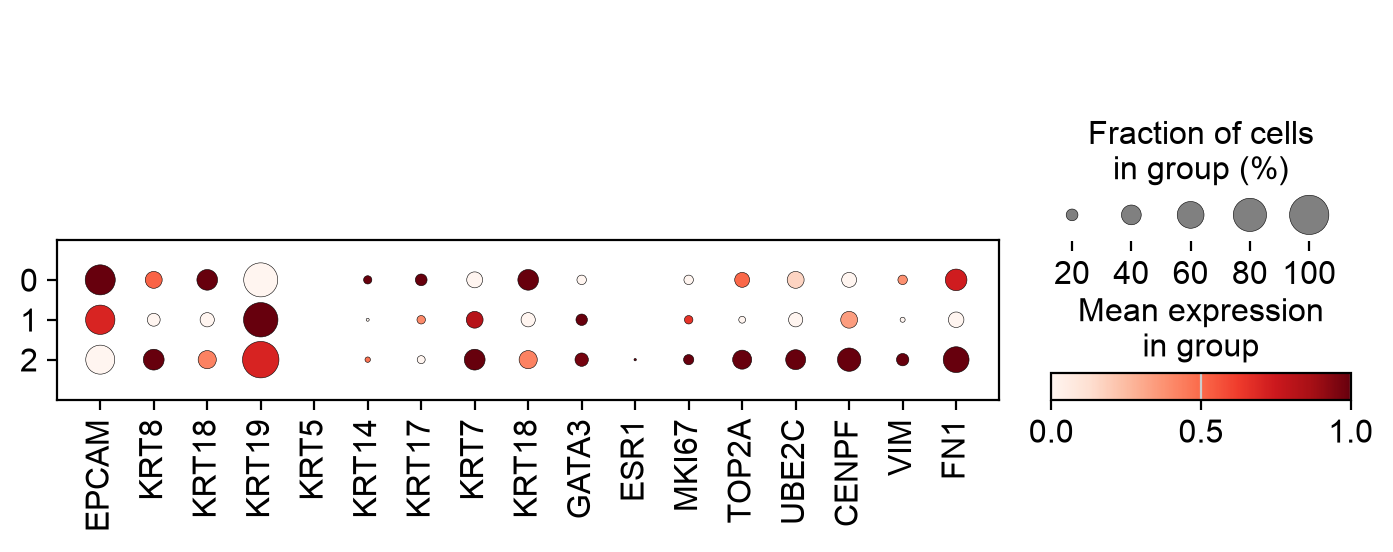

In [28]:
sc.pl.dotplot(
    tumor,
    var_names=available_markers,
    groupby="tumor_cluster",
    use_raw=True,
    standard_scale="var",
    show=True
)

In [29]:
# Assess statistical support for tumor-cluster markers

for cluster in sorted(tumor.obs["tumor_cluster"].unique()):
    
    df = marker_df[marker_df["group"] == cluster]

    print(f"\n=== Tumor Cluster {cluster} ===")
    print("Genes tested:", len(df))
    print("Adjusted p < 0.05:", (df["pvals_adj"] < 0.05).sum())
    print("Raw p < 0.05:", (df["pvals"] < 0.05).sum())
    print("Minimum raw p-value:", df["pvals"].min())
    print("Minimum adjusted p-value:", df["pvals_adj"].min())


=== Tumor Cluster 0 ===
Genes tested: 13514
Adjusted p < 0.05: 0
Raw p < 0.05: 41
Minimum raw p-value: 0.0007729969898971013
Minimum adjusted p-value: 1.0

=== Tumor Cluster 1 ===
Genes tested: 13514
Adjusted p < 0.05: 0
Raw p < 0.05: 72
Minimum raw p-value: 0.00039637930461433607
Minimum adjusted p-value: 1.0

=== Tumor Cluster 2 ===
Genes tested: 13514
Adjusted p < 0.05: 0
Raw p < 0.05: 64
Minimum raw p-value: 0.0031485921236552505
Minimum adjusted p-value: 1.0


Available markers:
['EPCAM', 'KRT8', 'KRT18', 'KRT19', 'KRT5', 'KRT14', 'KRT17', 'KRT7', 'GATA3', 'ESR1', 'MKI67', 'TOP2A', 'UBE2C', 'CENPF', 'VIM', 'FN1', 'VTCN1', 'LGALS3', 'HSPA1A', 'JUNB', 'GABRP', 'MAD2L1']


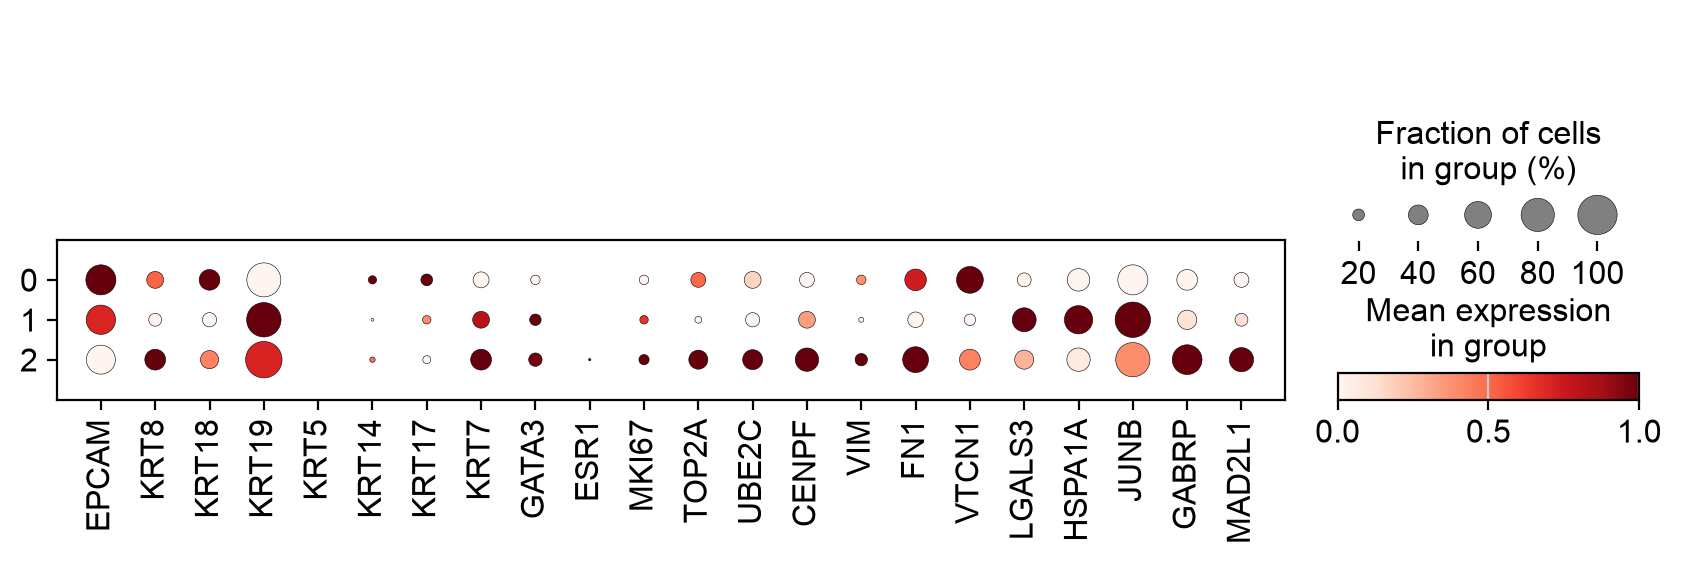

In [30]:
tumor_markers = [
    # Epithelial
    "EPCAM",
    "KRT8",
    "KRT18",
    "KRT19",

    # Basal
    "KRT5",
    "KRT14",
    "KRT17",
    "TP63",

    # Luminal-associated
    "KRT7",
    "GATA3",
    "ESR1",

    # Proliferation
    "MKI67",
    "TOP2A",
    "UBE2C",
    "CENPF",

    # EMT / mesenchymal
    "VIM",
    "FN1",

    # Candidate genes from our DE result
    "VTCN1",
    "LGALS3",
    "HSPA1A",
    "JUNB",
    "GABRP",
    "MAD2L1"
]

available_markers = [
    gene for gene in tumor_markers
    if gene in tumor.raw.var_names
]

print("Available markers:")
print(available_markers)

sc.pl.dotplot(
    tumor,
    var_names=available_markers,
    groupby="tumor_cluster",
    use_raw=True,
    standard_scale="var",
    show=True
)

In [31]:
# Define tumor transcriptional programs

proliferation_genes = [
    "MKI67", "TOP2A", "UBE2C", "CENPF", "MAD2L1"
]

basal_genes = [
    "KRT5", "KRT14", "KRT17", "TP63", "GABRP"
]

epithelial_genes = [
    "EPCAM", "KRT8", "KRT18", "KRT19", "TACSTD2"
]

stress_genes = [
    "HSPA1A", "HSPA1B", "JUN", "JUNB", "FOS", "FOSB"
]

gene_programs = {
    "Proliferation": proliferation_genes,
    "Basal": basal_genes,
    "Epithelial": epithelial_genes,
    "Stress": stress_genes
}

for score_name, genes in gene_programs.items():

    genes_present = [
        gene for gene in genes
        if gene in tumor.var_names
    ]

    print(f"{score_name}: {genes_present}")

    if len(genes_present) >= 2:
        sc.tl.score_genes(
            tumor,
            gene_list=genes_present,
            score_name=f"{score_name}_score",
            random_state=42
        )

Proliferation: ['MKI67', 'TOP2A', 'UBE2C', 'CENPF', 'MAD2L1']
computing score 'Proliferation_score'
    finished (0:00:00)
Basal: ['KRT5', 'KRT14', 'KRT17', 'GABRP']
computing score 'Basal_score'
    finished (0:00:00)
Epithelial: ['EPCAM', 'KRT8', 'KRT18', 'KRT19', 'TACSTD2']
computing score 'Epithelial_score'
    finished (0:00:00)
Stress: ['HSPA1A', 'HSPA1B', 'JUN', 'JUNB', 'FOS', 'FOSB']
computing score 'Stress_score'
    finished (0:00:00)


In [32]:
score_columns = [
    "Proliferation_score",
    "Basal_score",
    "Epithelial_score",
    "Stress_score"
]

cluster_scores = (
    tumor.obs
    .groupby("tumor_cluster", observed=True)[score_columns]
    .mean()
)

print(cluster_scores.round(3))

               Proliferation_score  Basal_score  Epithelial_score  \
tumor_cluster                                                       
0                            0.027       -0.142             0.215   
1                            0.030       -0.169             0.360   
2                            0.291       -0.059             0.239   

               Stress_score  
tumor_cluster                
0                     0.186  
1                     0.497  
2                     0.153  


In [33]:
# Assign conservative transcriptional-state annotations

tumor_state_map = {
    "0": "Intermediate epithelial",
    "1": "Stress-responsive epithelial",
    "2": "Proliferative"
}

tumor.obs["tumor_state"] = (
    tumor.obs["tumor_cluster"]
    .astype(str)
    .map(tumor_state_map)
)

print(tumor.obs["tumor_state"].value_counts())

tumor_state
Proliferative                   42
Intermediate epithelial         40
Stress-responsive epithelial    31
Name: count, dtype: int64


In [34]:
tumor_hvg.obs["tumor_state"] = (
    tumor.obs.loc[tumor_hvg.obs_names, "tumor_state"]
)

print(
    tumor_hvg.obs[
        ["leiden_0.5", "tumor_state"]
    ].value_counts()
)

leiden_0.5  tumor_state                 
2           Proliferative                   42
0           Intermediate epithelial         40
1           Stress-responsive epithelial    31
Name: count, dtype: int64


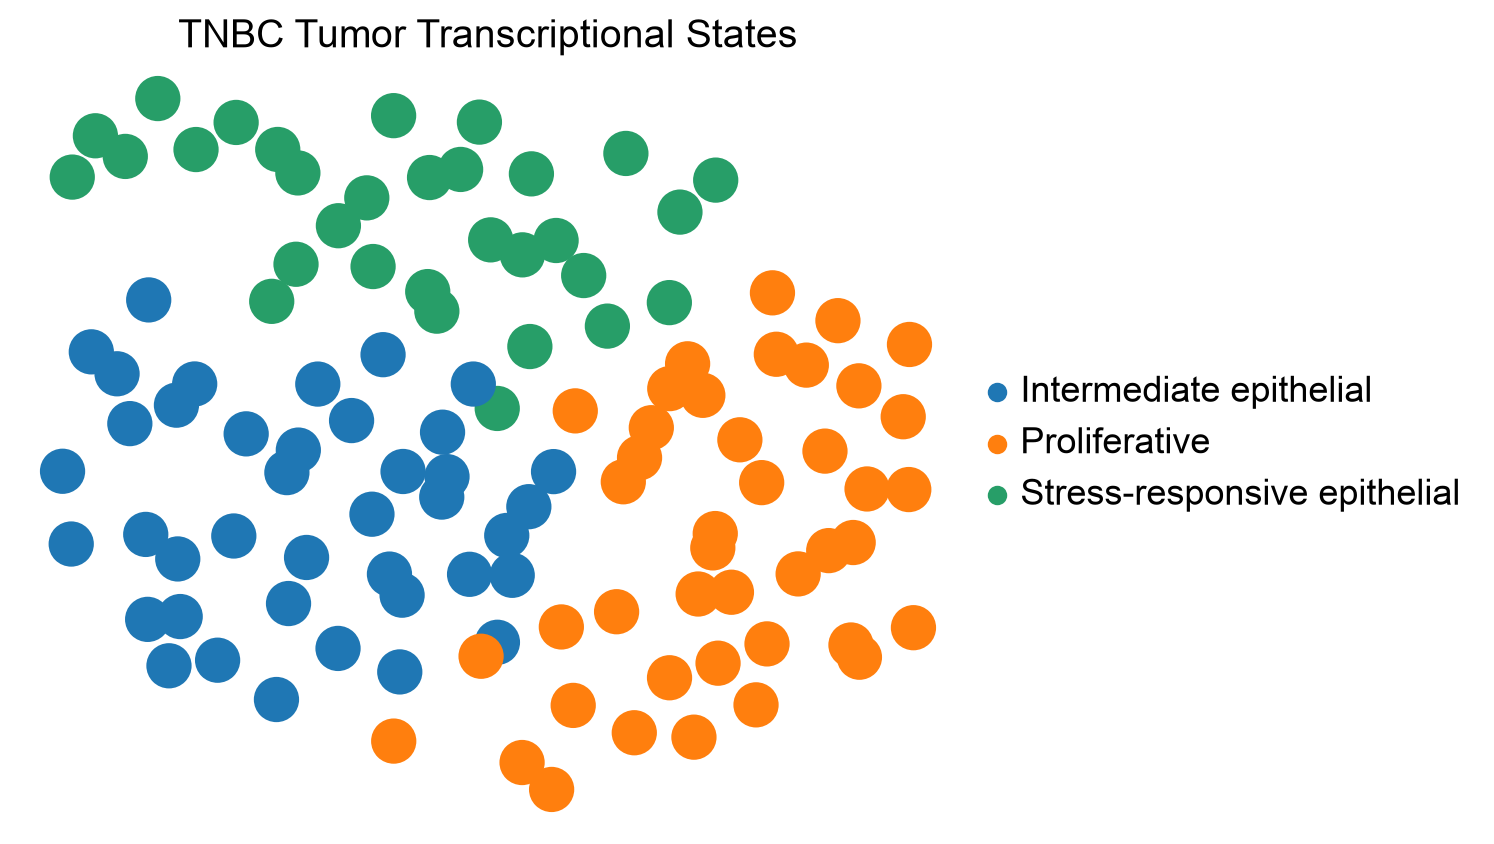

In [35]:
sc.pl.umap(
    tumor_hvg,
    color="tumor_state",
    title="TNBC Tumor Transcriptional States",
    legend_loc="right margin",
    frameon=False,
    show=True
)

In [36]:
from scipy.stats import kruskal

print("=== Gene-program score comparison ===")

for score in score_columns:

    groups = [
        tumor.obs.loc[
            tumor.obs["tumor_cluster"] == cluster,
            score
        ].dropna()
        for cluster in ["0", "1", "2"]
    ]

    stat, p = kruskal(*groups)

    print(
        f"{score}: "
        f"H = {stat:.3f}, "
        f"p = {p:.4g}"
    )

=== Gene-program score comparison ===
Proliferation_score: H = 6.559, p = 0.03764
Basal_score: H = 2.430, p = 0.2967
Epithelial_score: H = 1.624, p = 0.4439
Stress_score: H = 4.021, p = 0.1339


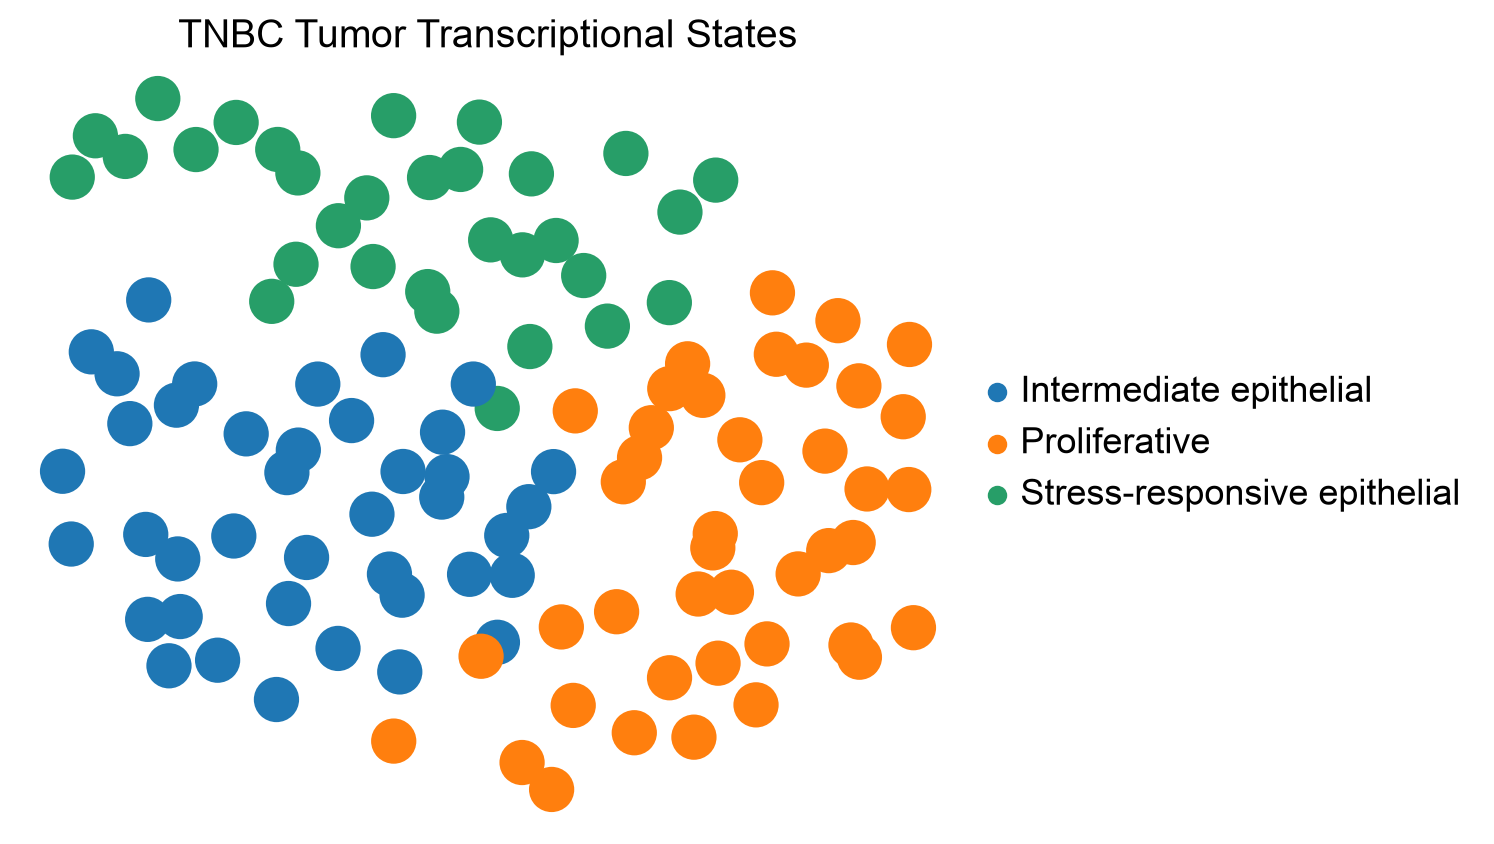

In [37]:
# Save final tumor-state UMAP

sc.pl.umap(
    tumor_hvg,
    color="tumor_state",
    title="TNBC Tumor Transcriptional States",
    legend_loc="right margin",
    frameon=False,
    show=False
)

plt.savefig(
    figures_dir / "05_tumor_transcriptional_states_umap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
# Copy gene-program scores from tumor to tumor_hvg

score_columns = [
    "Proliferation_score",
    "Basal_score",
    "Epithelial_score",
    "Stress_score"
]

for col in score_columns:
    tumor_hvg.obs[col] = tumor.obs.loc[
        tumor_hvg.obs_names,
        col
    ].values

print(
    tumor_hvg.obs[
        score_columns
    ].head()
)

                          Proliferation_score  Basal_score  Epithelial_score  \
CID4465_AATCCAGTCGGAATCT            -0.266439    -0.432476          0.892086   
CID4465_AGGCCACTCAATCACG            -0.410148    -0.400090         -0.802448   
CID4465_ATCACGACAATCGGTT             0.054902    -0.534981          0.317799   
CID4465_CTACACCTCGAGCCCA            -0.314827     0.346582          0.466188   
CID4465_TGGTTAGGTATAAACG            -0.343911    -0.396565          0.223621   

                          Stress_score  
CID4465_AATCCAGTCGGAATCT      0.647772  
CID4465_AGGCCACTCAATCACG     -0.016542  
CID4465_ATCACGACAATCGGTT      0.544706  
CID4465_CTACACCTCGAGCCCA      0.656197  
CID4465_TGGTTAGGTATAAACG     -0.209726  


In [40]:
print(tumor_hvg.obs.columns.tolist())

['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tumor_state', 'Proliferation_score', 'Basal_score', 'Epithelial_score', 'Stress_score']


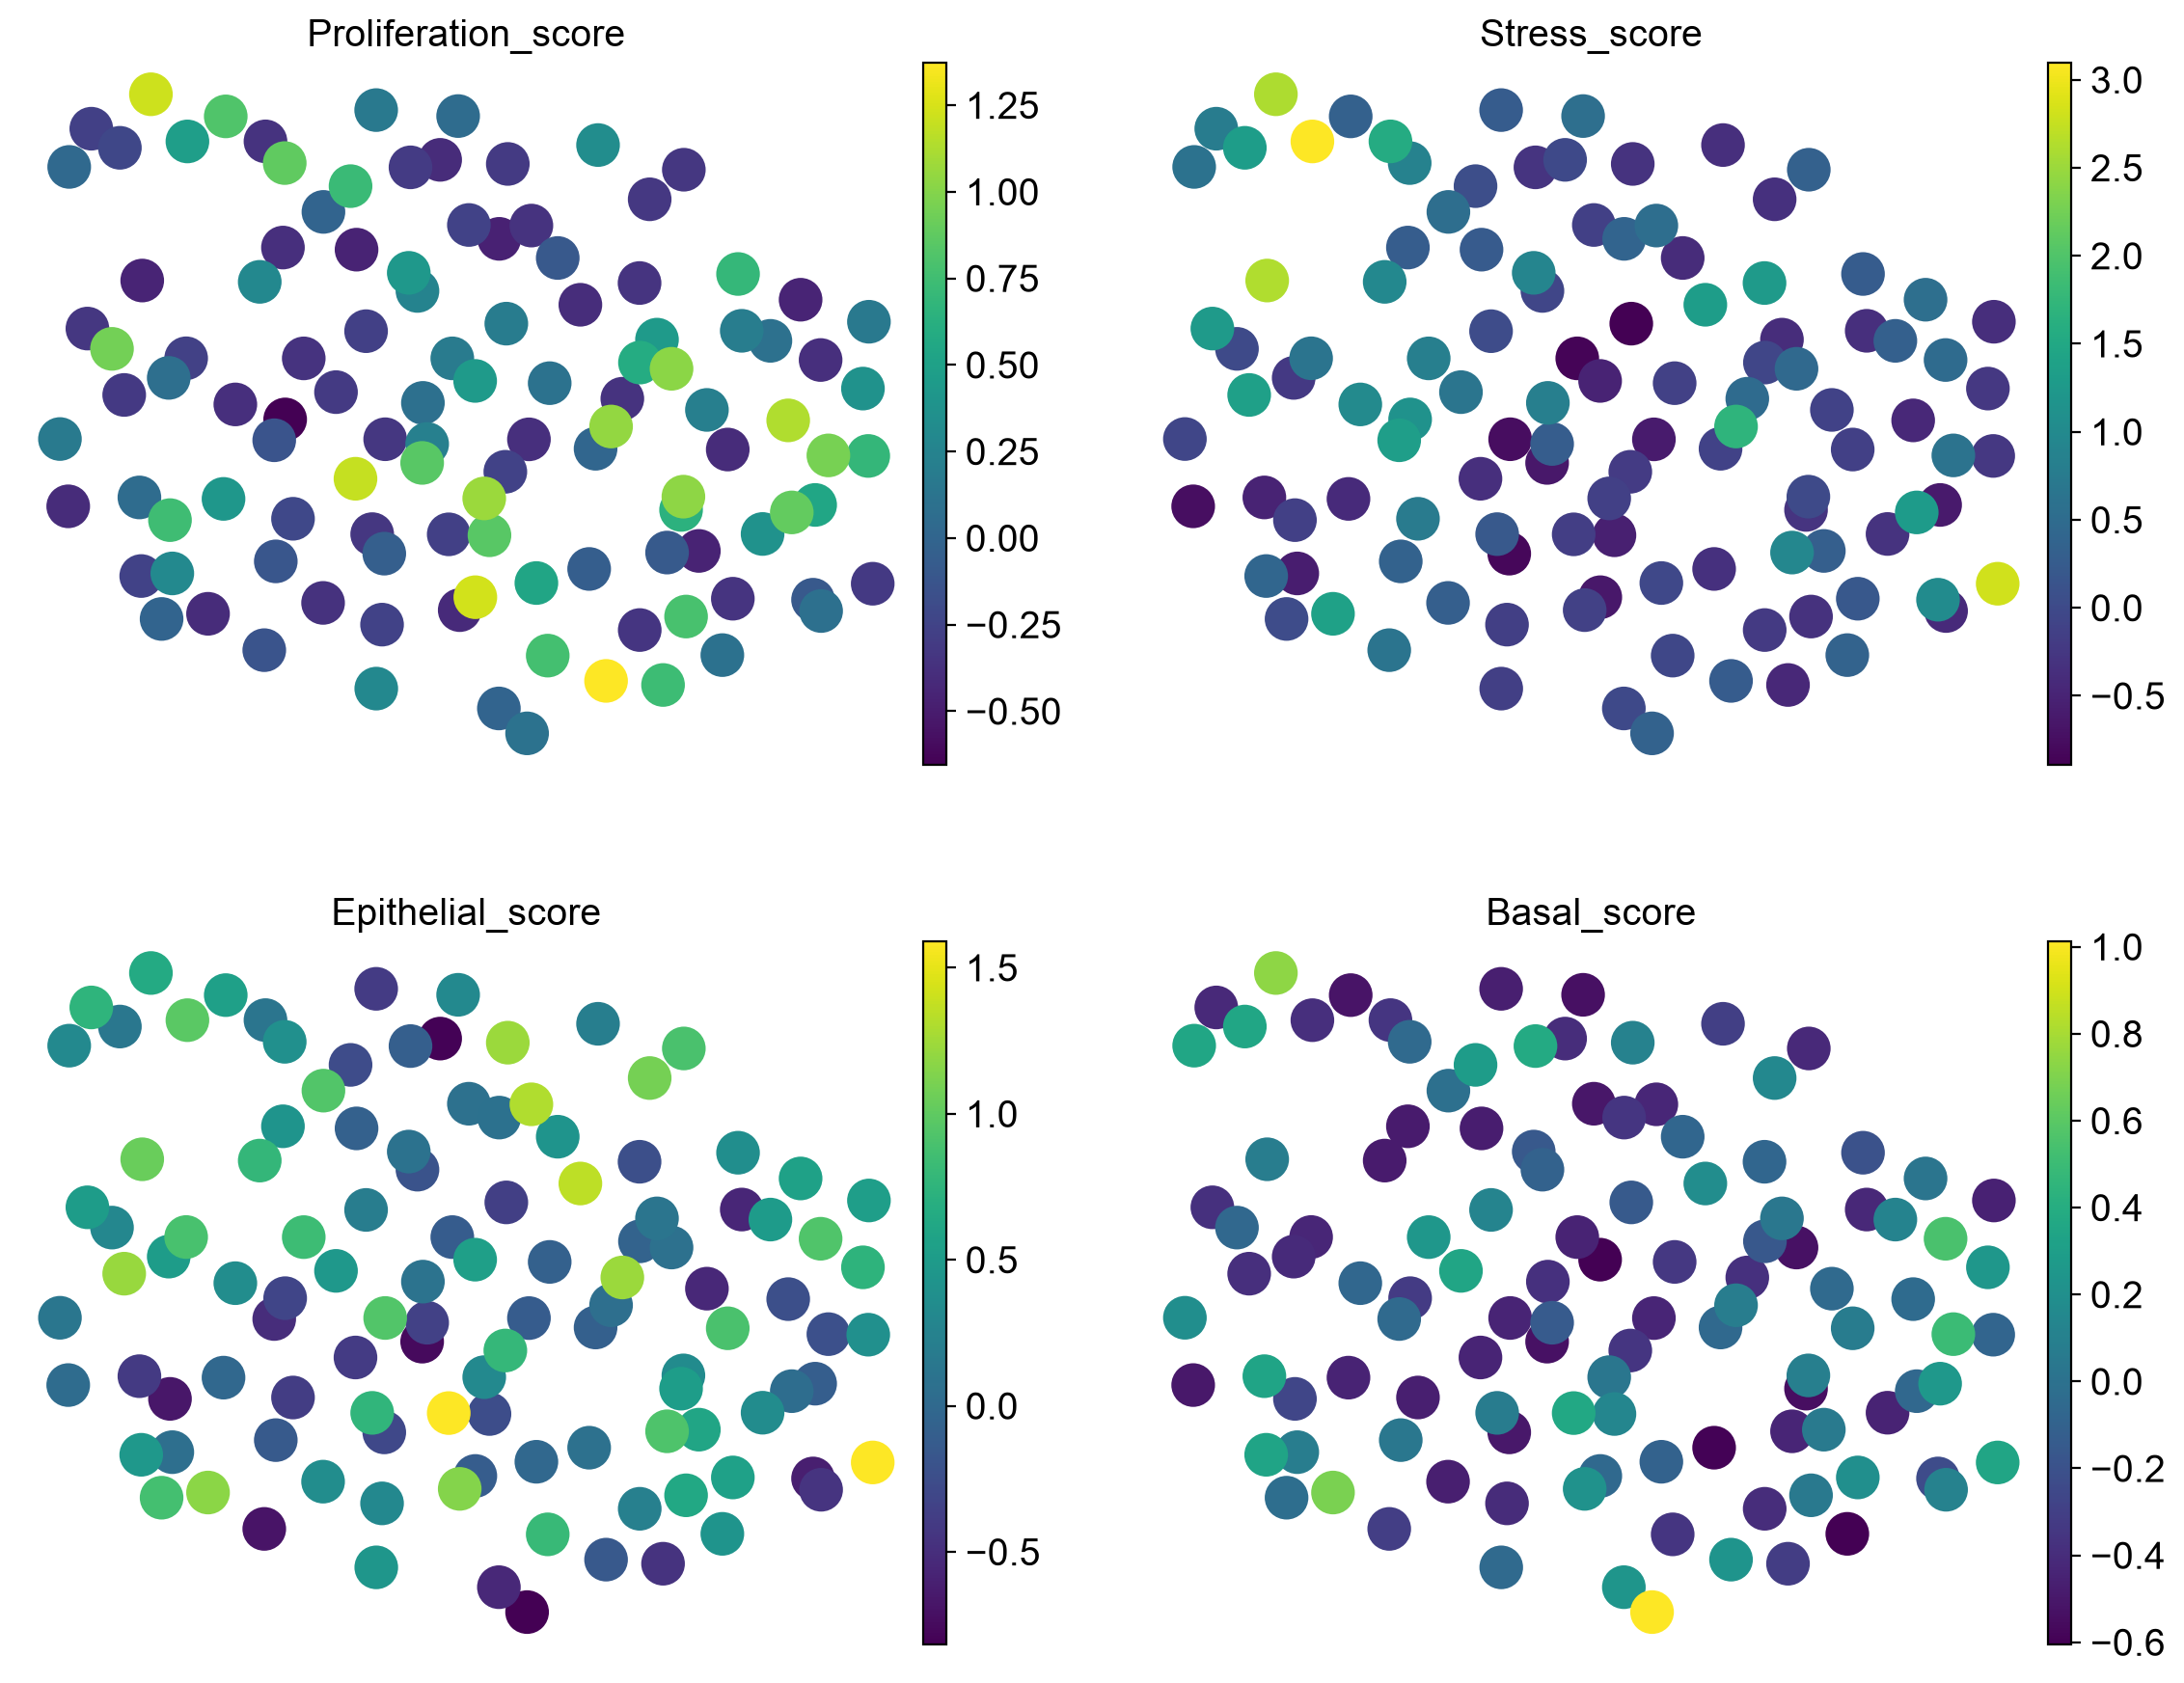

In [41]:
sc.pl.umap(
    tumor_hvg,
    color=[
        "Proliferation_score",
        "Stress_score",
        "Epithelial_score",
        "Basal_score"
    ],
    ncols=2,
    frameon=False,
    show=False
)

plt.savefig(
    figures_dir / "05_tumor_gene_program_scores_umap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
# Save cell-level tumor-state annotations

tumor_results = tumor.obs[
    [
        "celltype_minor",
        "celltype_subset",
        "tumor_cluster",
        "tumor_state",
        "Proliferation_score",
        "Basal_score",
        "Epithelial_score",
        "Stress_score"
    ]
].copy()

tumor_results.to_csv(
    results_dir / "05_tumor_cell_states.csv"
)

print("Saved tumor cell-state table:", tumor_results.shape)

Saved tumor cell-state table: (113, 8)


In [43]:
# Save tumor-state summary

cluster_summary = (
    tumor.obs
    .groupby(
        ["tumor_cluster", "tumor_state"],
        observed=True
    )
    .agg(
        n_cells=("tumor_state", "size"),
        mean_proliferation=("Proliferation_score", "mean"),
        mean_basal=("Basal_score", "mean"),
        mean_epithelial=("Epithelial_score", "mean"),
        mean_stress=("Stress_score", "mean")
    )
    .reset_index()
)

cluster_summary.to_csv(
    results_dir / "05_tumor_state_summary.csv",
    index=False
)

print(cluster_summary)

  tumor_cluster                   tumor_state  n_cells  mean_proliferation  \
0             0       Intermediate epithelial       40            0.027401   
1             1  Stress-responsive epithelial       31            0.029891   
2             2                 Proliferative       42            0.291206   

   mean_basal  mean_epithelial  mean_stress  
0   -0.142197         0.215316     0.186447  
1   -0.168899         0.360000     0.496736  
2   -0.058644         0.239317     0.152528  


In [44]:
print("=== FINAL TUMOR HETEROGENEITY QC ===")

print(f"Total cancer epithelial cells: {tumor.n_obs}")
print(f"Genes retained: {tumor.n_vars}")
print(f"Tumor-specific HVGs: {tumor_hvg.n_vars}")

print("\nTumor state distribution:")
print(
    tumor.obs["tumor_state"]
    .value_counts()
)

print("\nGene-program Kruskal-Wallis results:")
print("Proliferation: H = 6.559, p = 0.03764")
print("Basal:         H = 2.430, p = 0.2967")
print("Epithelial:    H = 1.624, p = 0.4439")
print("Stress:        H = 4.021, p = 0.1339")

print("\nDifferential-expression support:")
print("Significant cluster marker genes after multiple testing: 0")

print("\nInterpretation:")
print(
    "Tumor-only re-clustering identified three exploratory "
    "transcriptional states. The proliferative state showed "
    "a statistically significant difference in proliferation "
    "program score across clusters, whereas basal, epithelial, "
    "and stress programs were not significantly different."
)

=== FINAL TUMOR HETEROGENEITY QC ===
Total cancer epithelial cells: 113
Genes retained: 13514
Tumor-specific HVGs: 1500

Tumor state distribution:
tumor_state
Proliferative                   42
Intermediate epithelial         40
Stress-responsive epithelial    31
Name: count, dtype: int64

Gene-program Kruskal-Wallis results:
Proliferation: H = 6.559, p = 0.03764
Basal:         H = 2.430, p = 0.2967
Epithelial:    H = 1.624, p = 0.4439
Stress:        H = 4.021, p = 0.1339

Differential-expression support:
Significant cluster marker genes after multiple testing: 0

Interpretation:
Tumor-only re-clustering identified three exploratory transcriptional states. The proliferative state showed a statistically significant difference in proliferation program score across clusters, whereas basal, epithelial, and stress programs were not significantly different.


## Conclusion

Tumor-only re-clustering of 113 cancer epithelial cells identified three
exploratory transcriptional states:

- Intermediate epithelial
- Stress-responsive epithelial
- Proliferative

No individual cluster-marker genes remained significant after multiple-testing
correction, indicating limited statistical power within this relatively small
tumor-cell compartment.

Gene-program analysis nevertheless revealed a significant difference in
proliferation activity across clusters (Kruskal-Wallis p = 0.0376), with the
proliferative state showing the strongest cell-cycle-related expression.

Basal, epithelial, and stress-associated program scores did not differ
significantly across clusters.

Overall, these results support continuous functional heterogeneity within the
CID4465 TNBC malignant compartment rather than strongly separated tumor
subtypes.